In [1]:
0

0

#### Sending Data

In [5]:
image_path = r'C:\Users\shami\Tech\projects\quick-draw-proto\_98.png'

In [6]:
from PIL import Image

img_png = Image.open(image_path)

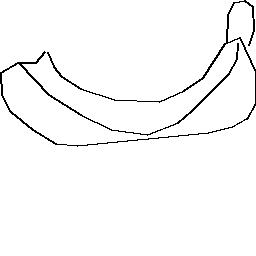

In [7]:
img_png

In [9]:
# to rgb

img_png = img_png.convert("RGB") 

In [10]:
# resizing will be done on client itself

img_png = img_png.resize((192,192))

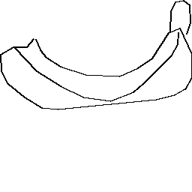

In [11]:
img_png

In [12]:
from io import BytesIO
jpeg_img = BytesIO()

In [13]:
img_png.save(jpeg_img, format='jpeg')
jpeg_bytes = jpeg_img.getvalue()

In [14]:
jpeg_bytes

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00\xc0\x00\xc0\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\

#### Recieving Data

In [15]:
jpeg_bytes

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00\xc0\x00\xc0\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\

In [18]:
img = Image.open(BytesIO(jpeg_bytes))

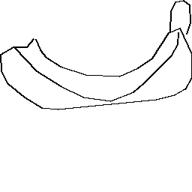

In [ ]:
img

In [23]:
import numpy as np

img_array = np.array(img).transpose(2, 0, 1).astype(np.float32) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [24]:
img_array.shape

(1, 3, 192, 192)

In [28]:
import onnxruntime as ort
import json

# Load vocabulary
with open("./vocab.json", "r") as f:
    vocab = json.load(f)

# Load ONNX model
session = ort.InferenceSession("./model.onnx")
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

In [29]:
# Run inference
outputs = session.run([output_name], {input_name: img_array})[0]
probs = np.exp(outputs) / np.sum(np.exp(outputs), axis=1)  # Softmax
pred_idx = np.argmax(probs, axis=1)[0]
pred = vocab[pred_idx]  # Map index to class name

# Print results
print(f"Prediction: {pred}")


Prediction: banana
